In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
class IQRClipper(BaseEstimator, TransformerMixin):

    def __init__(self, factor=1.5):
        self.factor = factor
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.lower_bounds = X.quantile(0.25) - self.factor * (X.quantile(0.75) - X.quantile(0.25))
        self.upper_bounds = X.quantile(0.75) + self.factor * (X.quantile(0.75) - X.quantile(0.25))
        return self
    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.clip(self.lower_bounds,self.upper_bounds,axis=1)
        return X.values

## Reading Data

---

In [3]:
data = pd.read_csv('CreditPrediction.csv')

In [4]:
# Rmoving extra columns
data = data.drop(columns=['CLIENTNUM','Unnamed: 19'])

In [5]:
# Removing duplicate rows
data = data.drop_duplicates().reset_index(drop=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10132 entries, 0 to 10131
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              10132 non-null  float64
 1   Gender                    9933 non-null   object 
 2   Dependent_count           10132 non-null  int64  
 3   Education_Level           10132 non-null  object 
 4   Marital_Status            8193 non-null   object 
 5   Income_Category           10132 non-null  object 
 6   Card_Category             8217 non-null   object 
 7   Months_on_book            9911 non-null   float64
 8   Total_Relationship_Count  10112 non-null  float64
 9   Months_Inactive_12_mon    10132 non-null  int64  
 10  Contacts_Count_12_mon     10132 non-null  int64  
 11  Credit_Limit              10132 non-null  float64
 12  Total_Revolving_Bal       10132 non-null  int64  
 13  Total_Amt_Chng_Q4_Q1      10132 non-null  float64
 14  Total_

## Feature Engineering

---

In [7]:
# Gender Encoding
data['Gender_numeric'] = data['Gender'].map({'M':1,'F':0})

In [8]:
# Education Level Encoding (Ordinal)
education_map = {'Uneducated': 0,'High School': 1,'College': 2,'Graduate': 3,'Post-Graduate': 4,'Doctorate': 5,'Unknown': np.nan}
data['Education_Level_encoded'] = data['Education_Level'].map(education_map)

In [9]:
# Marital Status Encoding
marital_map = {'Single': 0,'Married': 1,'Divorced': 2,'Unknown': np.nan}
data['Marital_Status_encoded'] = data['Marital_Status'].map(marital_map)

In [10]:
# Income Category Encoding (Ordinal)
income_map = {'Less than $40K': 1,'$40K - $60K': 2,'$60K - $80K': 3,'$80K - $120K': 4,'$120K +': 5,'Unknown': np.nan}
data['Income_Category_encoded'] = data['Income_Category'].map(income_map)

In [11]:
# Card Category Encoding (Ordinal)
card_map = {'Blue': 1,'Silver': 2,'Gold': 3,'Platinum': 4}
data['Card_Category_encoded'] = data['Card_Category'].map(card_map)

## X,Y definition

---

In [12]:
X = data.drop(columns=['Credit_Limit','Education_Level','Gender','Marital_Status','Income_Category','Card_Category'])
y = data['Credit_Limit']

In [13]:
X_train,X_test,y_train,y_test = train_test_split( X,y,test_size=0.2,random_state=42)

## EDA

---

In [14]:
corr = data.corr(numeric_only=True)

In [15]:
corr['Credit_Limit'].sort_values(ascending=False)

Credit_Limit                1.000000
Income_Category_encoded     0.599157
Card_Category_encoded       0.494148
Gender_numeric              0.419910
Total_Trans_Amt             0.171779
Total_Trans_Ct              0.075927
Dependent_count             0.068068
Total_Revolving_Bal         0.042590
Contacts_Count_12_mon       0.020836
Total_Amt_Chng_Q4_Q1        0.012901
Months_on_book              0.007591
Customer_Age                0.004239
Total_Ct_Chng_Q4_Q1        -0.001819
Education_Level_encoded    -0.009109
Months_Inactive_12_mon     -0.020253
Marital_Status_encoded     -0.022214
Total_Relationship_Count   -0.071408
Avg_Utilization_Ratio      -0.482793
Name: Credit_Limit, dtype: float64

Income_Category_encoded (0.599): The higher the income level, the higher the credit limit. This relationship makes sense. Card_Category_encoded (0.494): Gold and Platinum cards typically have higher credit limits than Blue. Gender_numeric (0.413): This correlation is relatively high, but should be interpreted with caution. Avg_Utilization_Ratio (-0.483): The higher the credit utilization ratio, the lower the credit limit is typically in this dataset; therefore, the correlation is negative.

C:\Users\Sharif\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


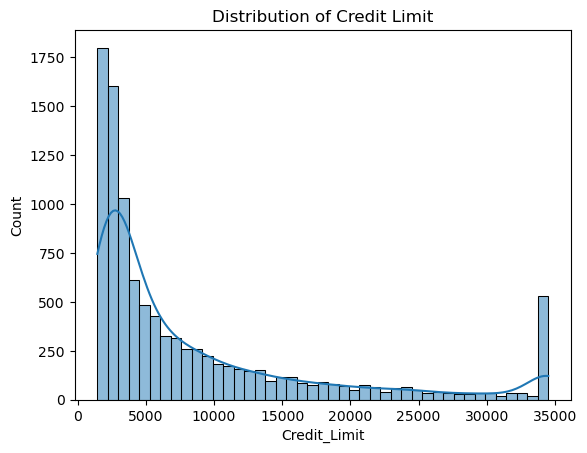

In [16]:
# Distribution of target variable
import seaborn as sns 
import matplotlib.pyplot as plt
sns.histplot(y, kde=True)
plt.title("Distribution of Credit Limit")
plt.show()

<Axes: xlabel='Income_Category_encoded', ylabel='Credit_Limit'>

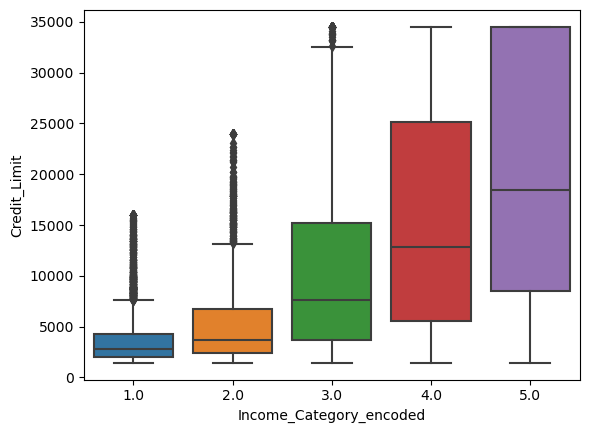

In [17]:
# Relationship between income and credit limit
sns.boxplot(x='Income_Category_encoded', y=y, data=data)

People with higher incomes have higher credit limits.

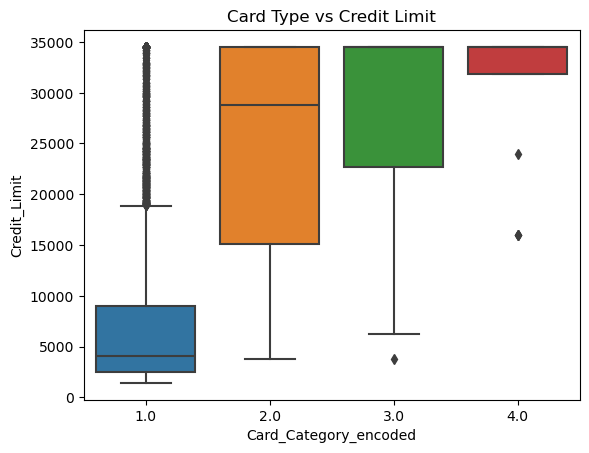

In [18]:
# Card Type and Credit Limit

sns.boxplot(x='Card_Category_encoded', y=y, data=data)
plt.title("Card Type vs Credit Limit")
plt.show()

Gold/Platinum cards have a higher limit. Blue has the lowest.

## Model comparison

---

In [19]:
from sklearn.linear_model import LinearRegression ,Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
models = {
  "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [20]:
results = []

In [21]:
df_numerical_cols=['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 
    'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

In [22]:
for name, model in models.items():
    # create pipeline for each model
    pipeline = Pipeline([('imputer', KNNImputer(n_neighbors=5)),
                        ('outlier_clipping', IQRClipper(factor=1.5)),
                        ('scaler', StandardScaler()),
                        ('model', model)])
     # train
    pipeline.fit(X_train, y_train)

    # prediction
    y_pred = pipeline.predict(X_test)

    # metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # save results
    results.append({'Model': name,'MAE': mae,'MSE': mse,'RMSE': rmse,'R²': r2})

In [23]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R²',ascending=False)
print(results_df)

               Model          MAE           MSE         RMSE        R²
4      Random Forest  1476.280612  1.421992e+07  3770.931227  0.832961
5  Gradient Boosting  1823.316232  1.435219e+07  3788.428614  0.831407
3      Decision Tree  1936.579477  2.623739e+07  5122.244198  0.691794
2              Lasso  4716.463402  4.064604e+07  6375.424629  0.522538
1              Ridge  4716.322444  4.064647e+07  6375.458349  0.522533
0  Linear Regression  4716.513227  4.064659e+07  6375.468093  0.522532


Linear / Ridge / Lasso
Weaker (R² ≈ 0.50)
This means the data relationship is not linear.

<Axes: xlabel='Credit_Limit'>

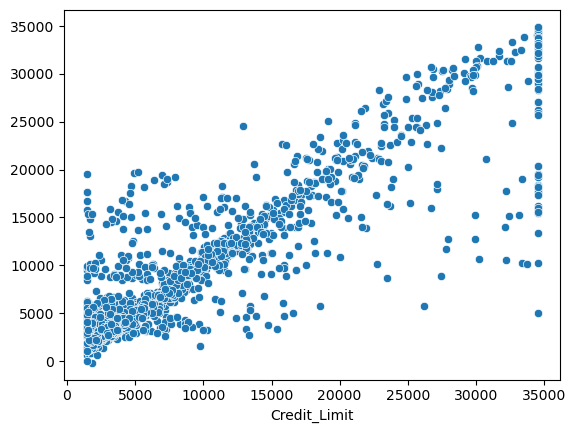

In [24]:
sns.scatterplot(x=y_test, y=y_pred)

In [25]:
pip install fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.


In [43]:
from fastapi import FastAPI
import joblib
from iqr_clipper import IQRClipper

ModuleNotFoundError: No module named 'iqr_clipper'

In [34]:
app = FastAPI()

In [41]:
model = joblib.load("C:\\Users\\Sharif\\models\\credit_limit_model.pkl")

In [42]:
@app.post("/predict")
def predict(data: dict):
    df = pd.DataFrame([data])
    prediction = model.predict(df)
    return {"predicted_credit_limit": float(prediction[0]) }